# Mimic IV Dataset – Exploratory Data Analysis (EDA)

Focus:
- Feature distributions
- Missing (null) values



## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

real_path = 'Fake_Datasets/MimicIV/MimicIV_fake_4.csv'
df = pd.read_csv(real_path)

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (24230, 34)


,subject_id,hadm_id,stay_id,gender,age_at_intime,heart_rate_min,heart_rate_max,heart_rate_mean,sbp_min,sbp_max,...,creatinine_max,sodium_min,sodium_max,potassium_min,potassium_max,hemoglobin_min,hemoglobin_max,wbc_min,wbc_max,hospital_expire_flag
0,1.047657e+07,2.350666e+07,3.674029e+07,M,50,87.434654,144.974808,115.550484,77.017052,129.552155,...,0.812661,139.578751,141.919662,2.302271,3.871830,12.726539,14.881943,12.536478,13.010362,0
1,1.263912e+07,2.298541e+07,3.401365e+07,F,84,66.571030,78.453316,81.837700,92.254585,139.026291,...,0.689621,138.717590,141.354050,3.529291,3.795627,5.497646,10.352620,7.103278,13.025280,0
2,1.412256e+07,2.329410e+07,3.524945e+07,M,30,93.424393,141.583038,100.299011,96.054268,148.431564,...,0.774943,136.501999,139.671249,2.558053,4.617000,11.551456,15.276245,15.154925,12.299990,0
3,1.772001e+07,2.958669e+07,3.372976e+07,M,59,89.261253,95.150856,90.187256,125.808685,121.546890,...,0.452611,139.491028,141.022156,3.716197,4.445978,11.942506,11.997126,12.607882,10.238570,0
4,1.830757e+07,2.462760e+07,3.471460e+07,M,45,92.439857,115.519424,102.837067,132.202255,150.649460,...,1.031369,125.648605,130.500763,4.408145,4.304477,10.894567,8.539098,18.466372,22.319376,1


## 2. Data Types

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24230 entries, 0 to 24229
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   subject_id            24230 non-null  float64
 1   hadm_id               24230 non-null  float64
 2   stay_id               24230 non-null  float64
 3   gender                24230 non-null  object 
 4   age_at_intime         24230 non-null  int64  
 5   heart_rate_min        23640 non-null  float64
 6   heart_rate_max        23473 non-null  float64
 7   heart_rate_mean       23305 non-null  float64
 8   sbp_min               23312 non-null  float64
 9   sbp_max               23480 non-null  float64
 10  sbp_mean              23357 non-null  float64
 11  dbp_min               23338 non-null  float64
 12  dbp_max               23374 non-null  float64
 13  dbp_mean              23458 non-null  float64
 14  resp_rate_min         23468 non-null  float64
 15  resp_rate_max      

## 3. Missing Values

In [3]:
missing_abs = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    'missing_count': missing_abs,
    'missing_percent': missing_pct
})

total_cells = df.shape[0] * df.shape[1]
total_missing = df.isna().sum().sum()

missing_percentage = (total_missing / total_cells) * 100
print("total missing values:", missing_percentage)

missing_df[missing_df.missing_count > 0].head(20)

total missing values: 2.797577140637518


,missing_count,missing_percent
temperature_mean,1683,6.945935
temperature_min,1353,5.583987
temperature_max,1303,5.377631
spo2_max,1294,5.340487
heart_rate_mean,925,3.817582
sbp_min,918,3.788692
dbp_min,892,3.681387
sbp_mean,873,3.602972
dbp_max,856,3.532811
spo2_min,855,3.528683


## 4. Missing Values Plot

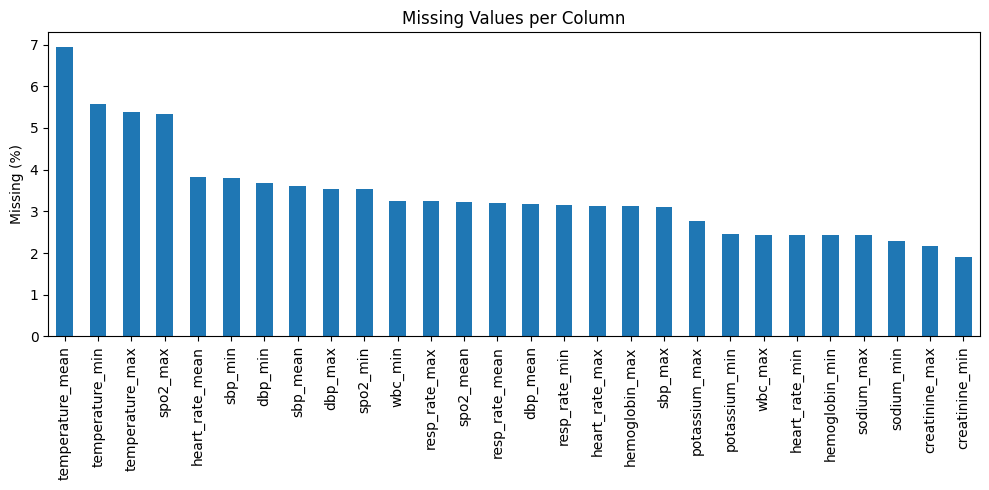

In [4]:
plt.figure(figsize=(10,5))
missing_pct[missing_pct > 0].plot(kind='bar')
plt.ylabel('Missing (%)')
plt.title('Missing Values per Column')
plt.tight_layout()
plt.show()

In [5]:
df_filtered = df[df.notna().sum(axis=1) >= 10]
print("Original shape:", df.shape)
print("Filtered shape:", df_filtered.shape)

print("Rows removed:", df.shape[0] - df_filtered.shape[0])

x = 30  # threshold in percent

missing_pct = df_filtered.isna().mean() * 100
df_filtered2 = df_filtered.loc[:, missing_pct <= x]

removed = set(df_filtered.columns) - set(df_filtered2.columns)
print("Dropped columns:", removed)

print("Filtered2 shape:", df_filtered2.shape)


Original shape: (24230, 34)
Filtered shape: (24219, 34)
Rows removed: 11
Dropped columns: set()
Filtered2 shape: (24219, 34)


## 5. Numeric Distributions

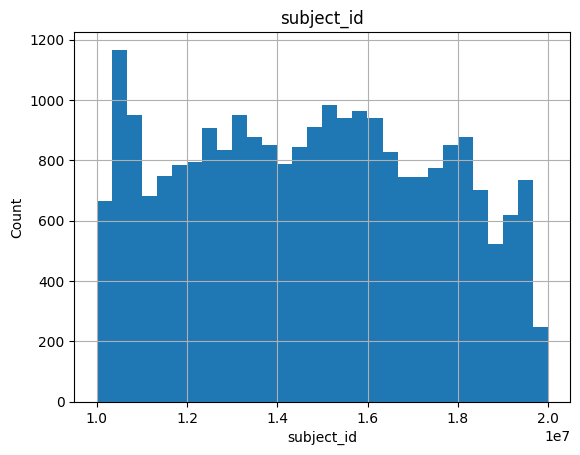

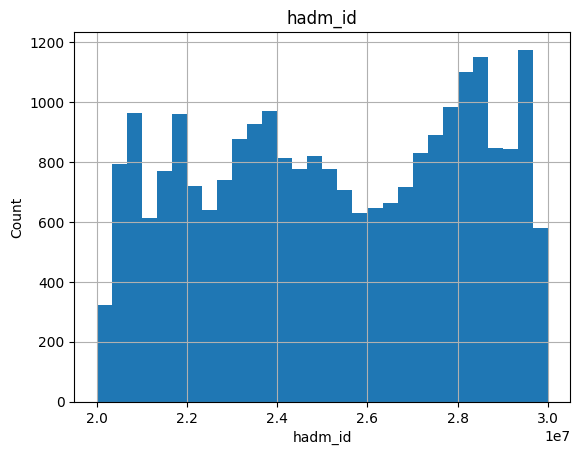

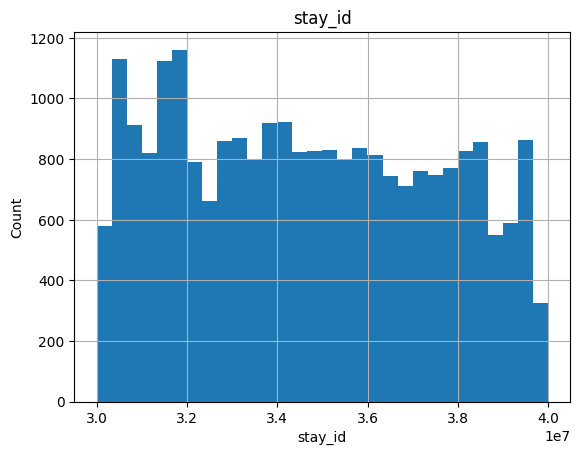

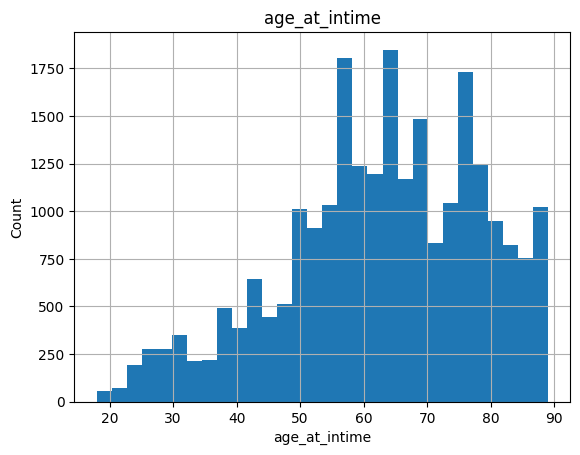

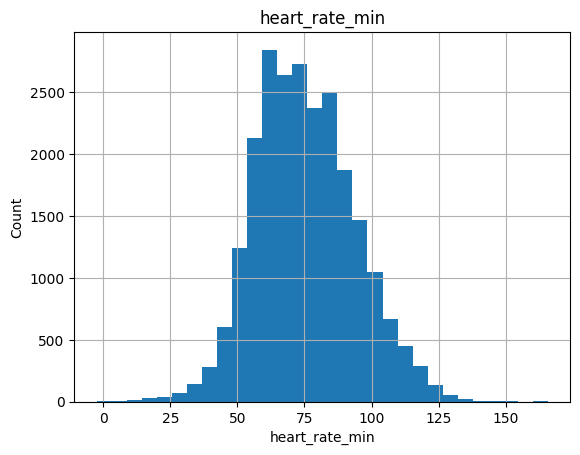

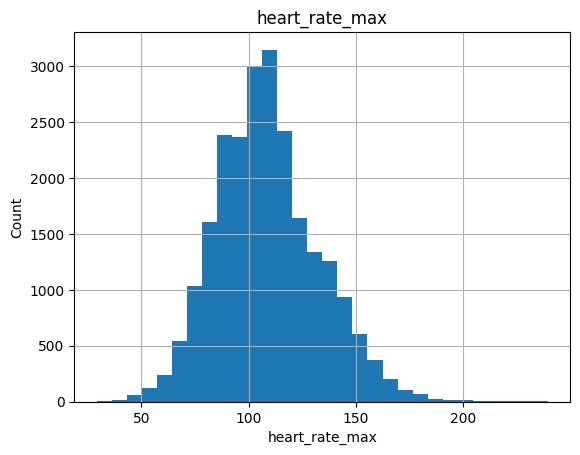

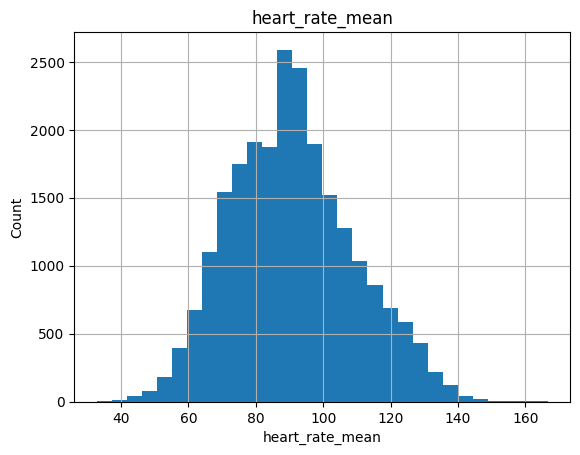

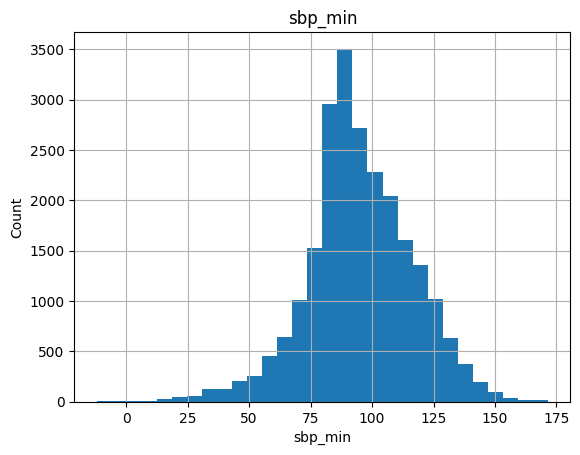

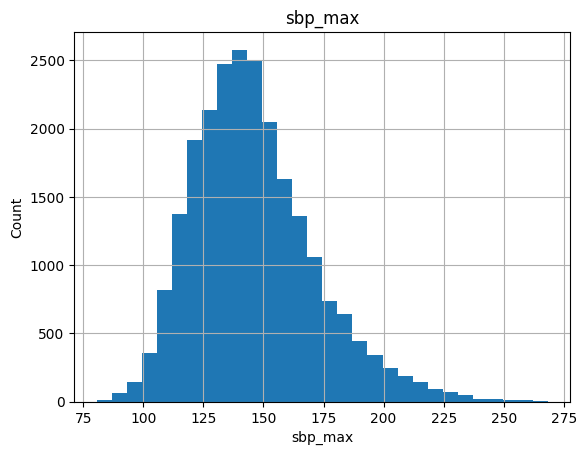

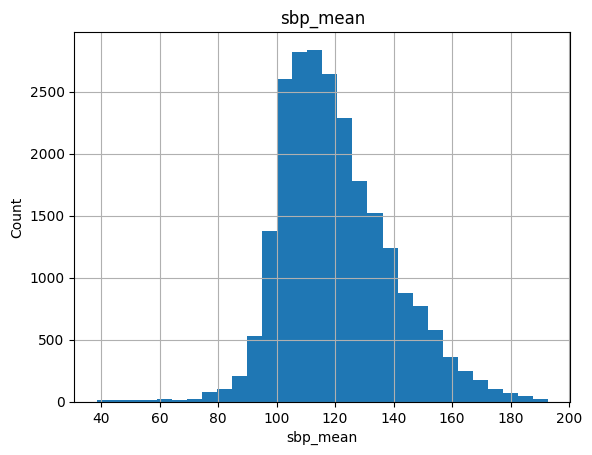

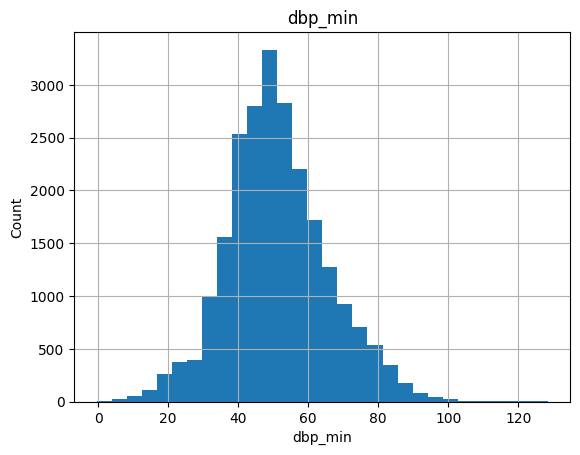

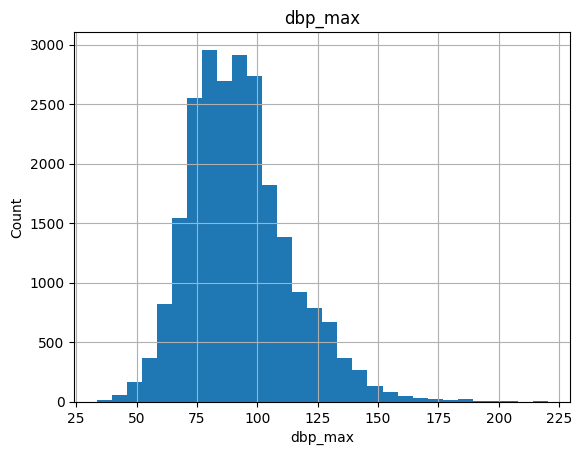

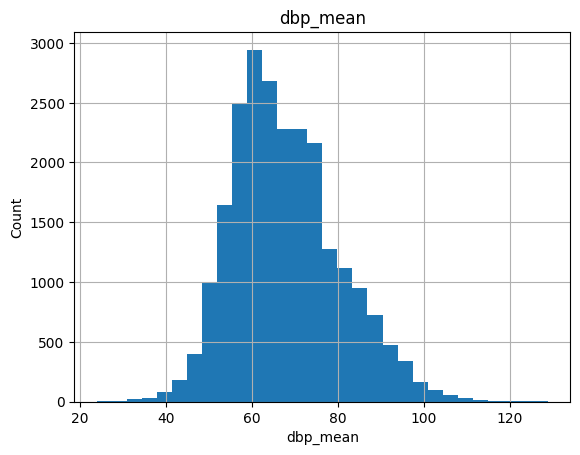

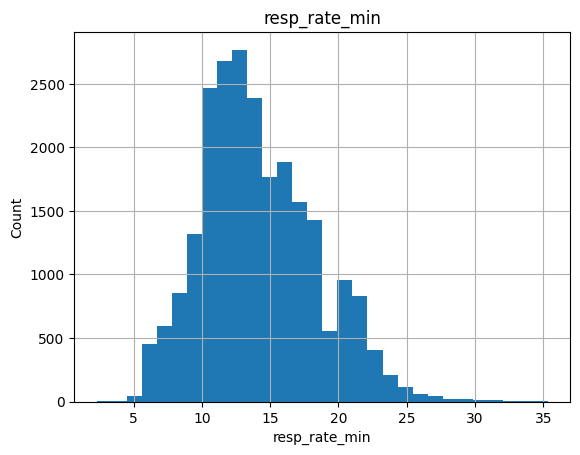

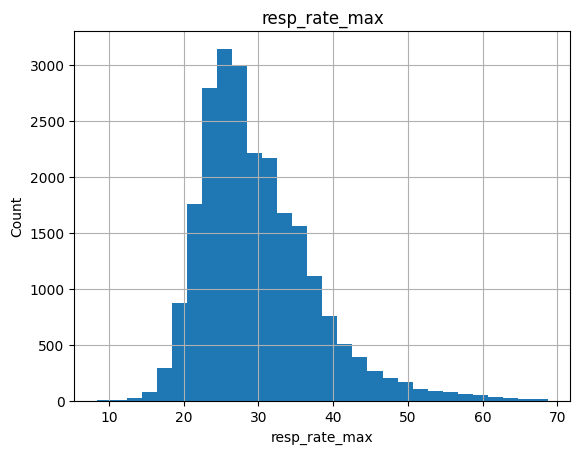

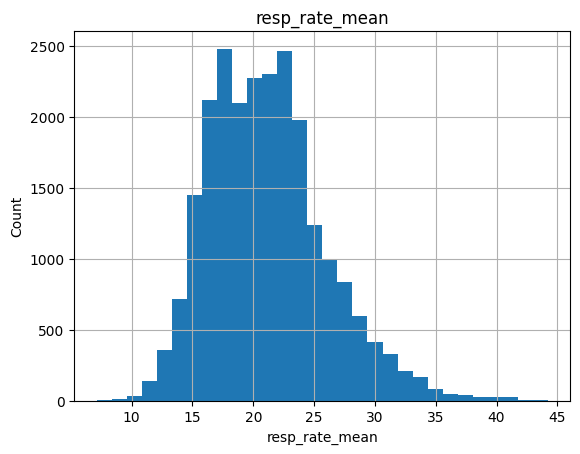

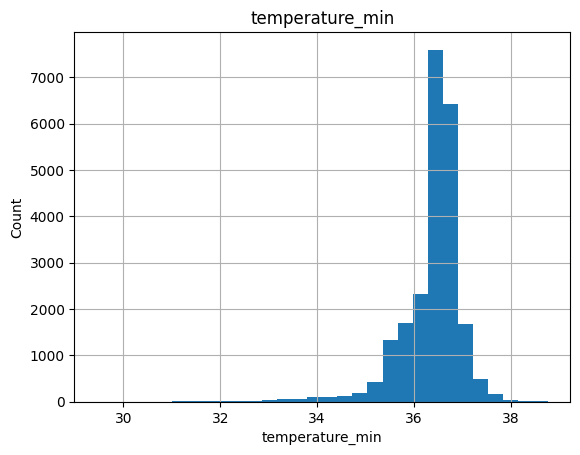

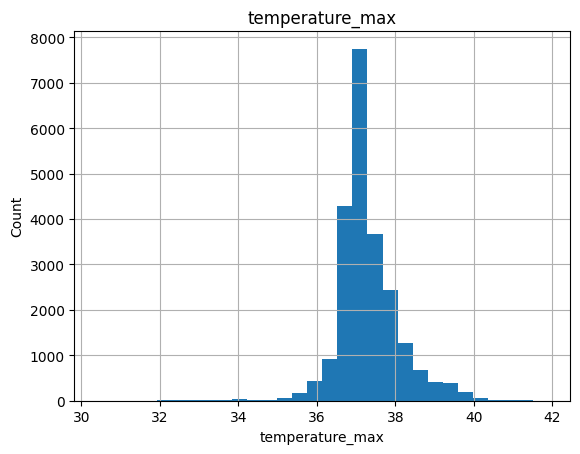

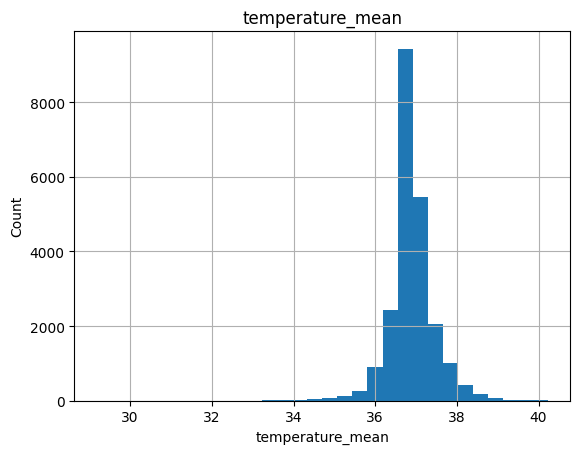

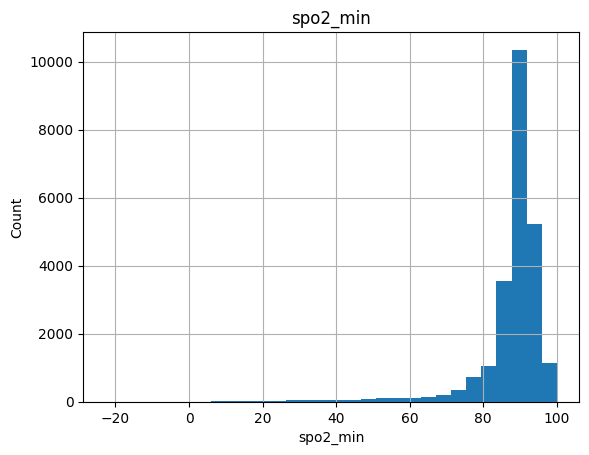

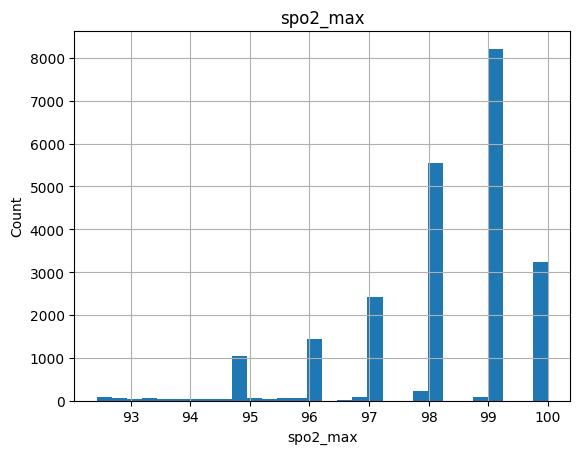

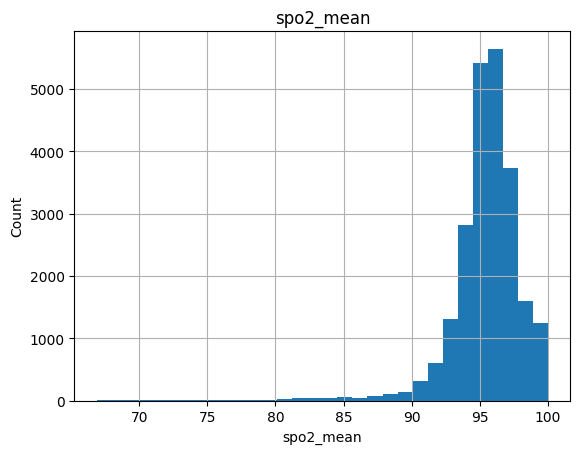

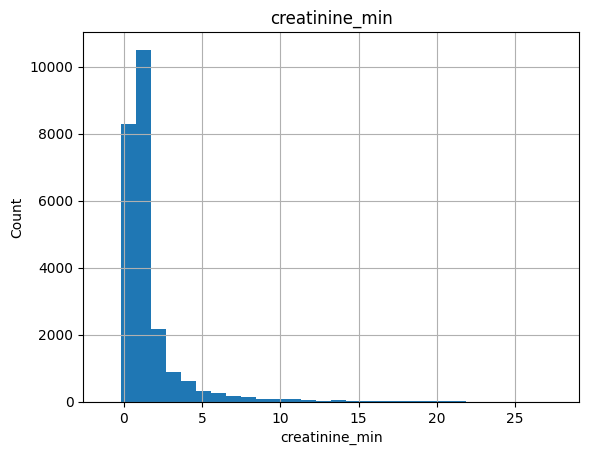

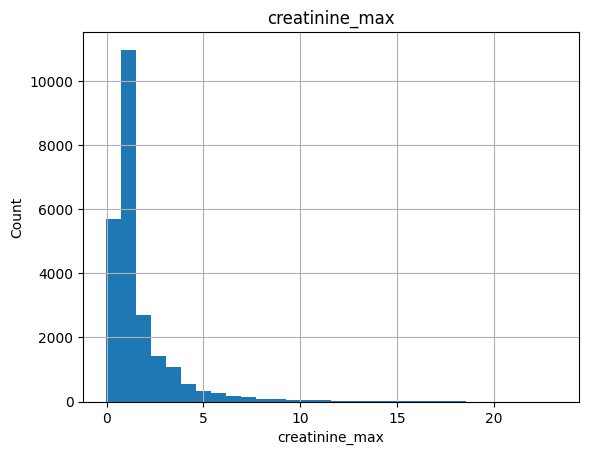

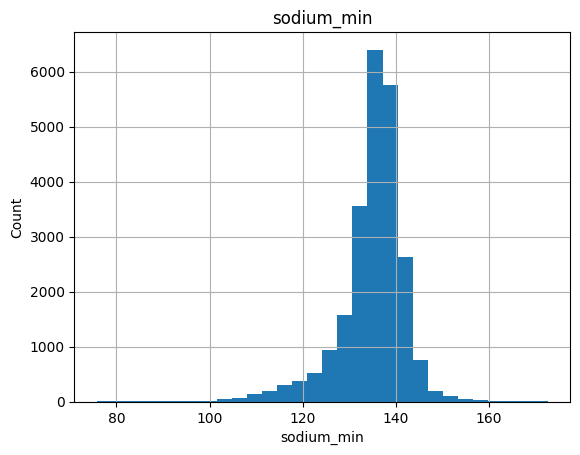

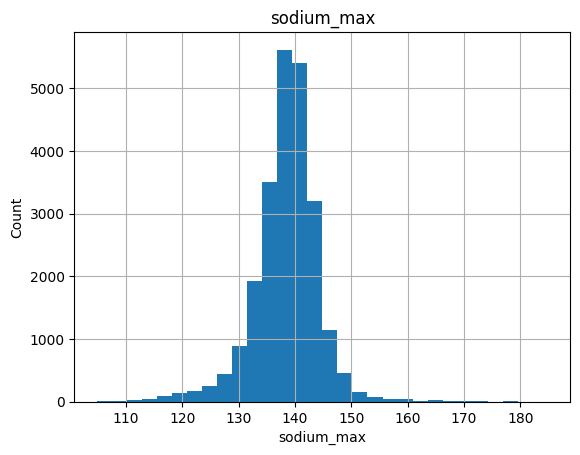

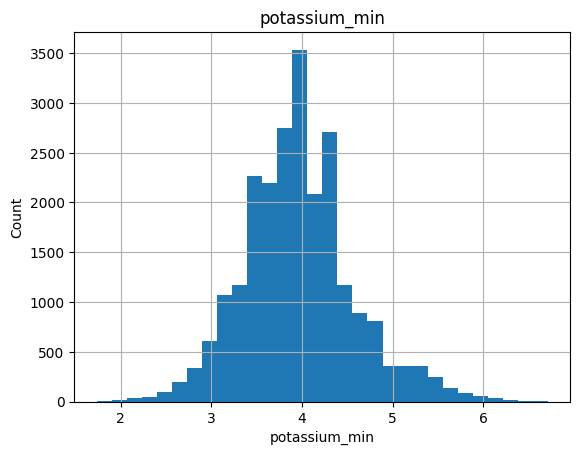

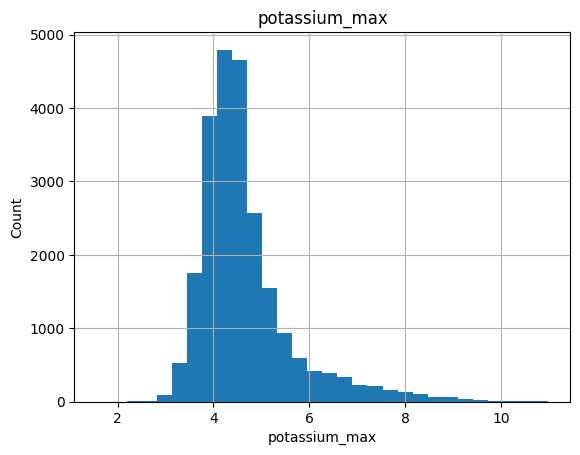

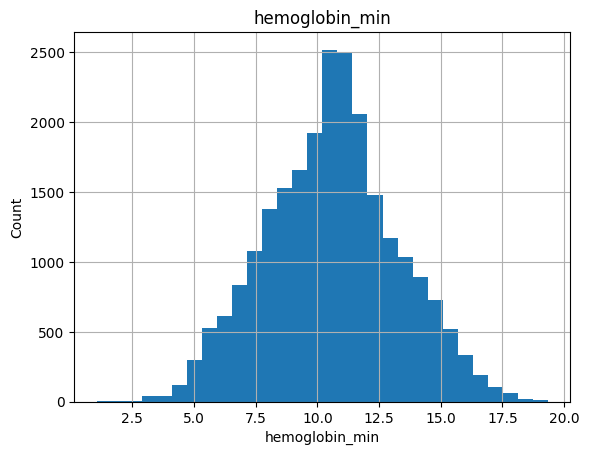

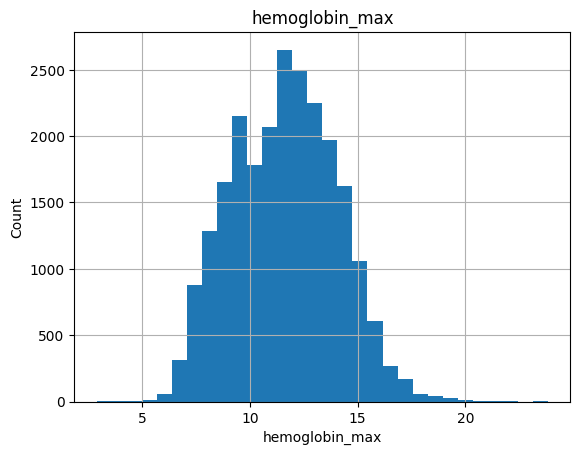

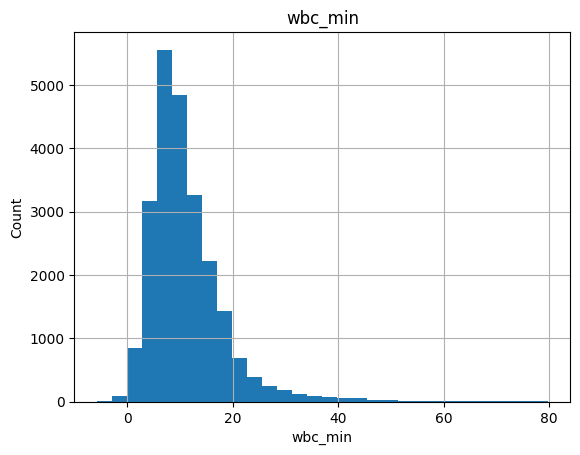

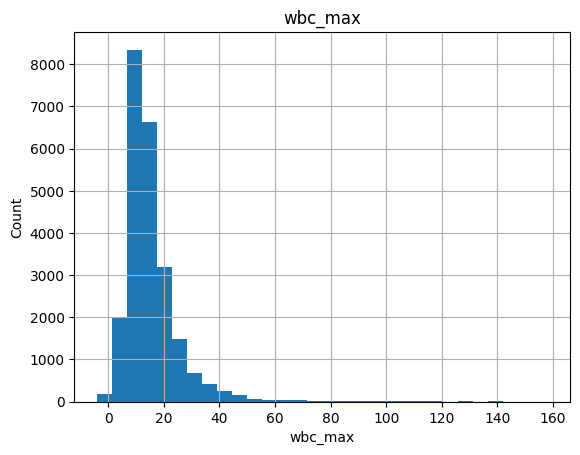

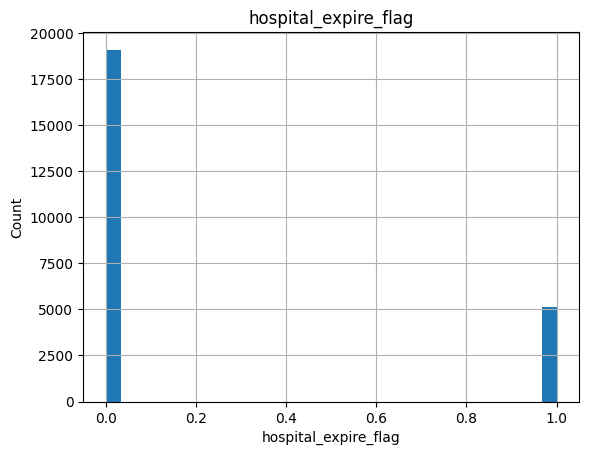

In [6]:
num_cols = df_filtered2.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    plt.figure()
    df_filtered2[col].dropna().hist(bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

## 6. Categorical Distributions

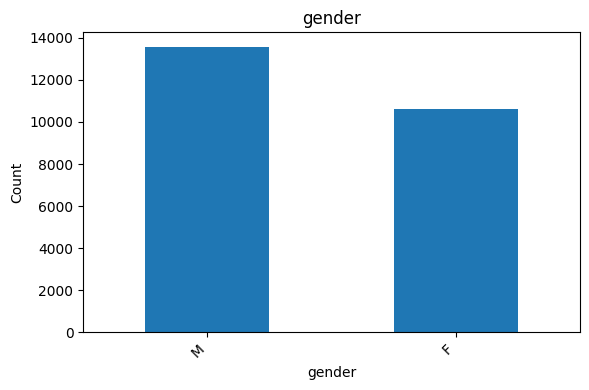

In [7]:
cat_cols = df_filtered2.select_dtypes(exclude=[np.number]).columns.tolist()
for col in cat_cols:
    plt.figure(figsize=(6,4))
    df_filtered2[col].value_counts(dropna=False).head(20).plot(kind='bar')
    plt.title(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 7. Notes
- Columns with high missingness may need imputation or removal
- Highly skewed distributions may require transformation before GAN training